# Data Prep — Hand in Pocket

Bangun dataset training **detection (bbox)** untuk deteksi tangan-di-saku, dari `research/datasets/raw/hand_in_pocket_1/` (Roboflow `hand-in-pocket-detection` v6).

**2 kelas:**
- `0 = hand_in_pocket` — tangan masuk saku (violation)
- `1 = no_hand_in_pocket` — tangan terlihat / tidak di saku (di raw bernama `not_hand_in_pocket`, di-rename ikut konvensi prefix `no_` di CLAUDE.md)

**Catatan format:** label raw sebenarnya sudah **bbox** (5 field per baris). Sempat terlihat seperti polygon karena file raw tidak diakhiri newline — saat di-`cat` beruntun, baris antar-file menempel. Fungsi konversi di bawah tetap polygon-safe (auto bbox dari polygon) supaya reusable saat menggabung dataset #2 (`segmentation-hand-in-pocket`) di Fase A.2.

**Output:** `research/datasets/processed/hand_in_pocket/{train,valid}/{images,labels}` + `data.yaml`.

## Alur
1. Setup
2. Konversi raw #1 → processed (relabel + polygon-safe bbox + trailing newline)
3. Profil dataset (distribusi kelas, ukuran bbox)
4. (Opsional) Gabung dataset #2
5. Sample gambar + bbox

## Setup

In [1]:
%matplotlib inline
from __future__ import annotations

import random
import shutil
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
import yaml
from PIL import Image

NOTEBOOK_DIR = Path.cwd()
RESEARCH_DIR = NOTEBOOK_DIR.parents[1]   # research/
AI_DIR       = NOTEBOOK_DIR.parents[2]   # ai/

RAW1_DIR = RESEARCH_DIR / 'datasets' / 'raw' / 'hand_in_pocket_1'
RAW2_DIR = RESEARCH_DIR / 'datasets' / 'raw' / 'hand_in_pocket_2'
PROC_DIR = RESEARCH_DIR / 'datasets' / 'processed' / 'hand_in_pocket'
DATA_YAML = PROC_DIR / 'data.yaml'

CLASS_NAMES = ['hand_in_pocket', 'no_hand_in_pocket']
SPLITS = ['train', 'valid']
SEED = 42

if not RAW1_DIR.exists():
    raise FileNotFoundError(f'Nggak ketemu: {RAW1_DIR}')
print('Raw #1   :', RAW1_DIR)
print('Processed:', PROC_DIR)

Raw #1   : c:\Users\istd.magang125\OneDrive - TMMIN\Documents\cctv-insight\ai\research\datasets\raw\hand_in_pocket_1
Processed: c:\Users\istd.magang125\OneDrive - TMMIN\Documents\cctv-insight\ai\research\datasets\processed\hand_in_pocket


## Konversi raw #1 → processed

Set `OVERWRITE_PROCESSED = True` kalau mau rebuild (mahal-ish, copy gambar). Default `False` — kalau `processed/` udah ada, skip.

`ext()` pakai prefix Windows `\\?\` buat hindari limit path 260 karakter (folder OneDrive + nama file panjang dari Roboflow).

In [2]:
OVERWRITE_PROCESSED = False


def ext(p: Path) -> Path:
    """Windows extended-length path — hindari MAX_PATH 260 char (folder OneDrive + nama file panjang)."""
    return Path('\\\\?\\' + str(p.resolve()))


def poly_to_bbox(coords):
    xs, ys = coords[0::2], coords[1::2]
    xmin, xmax, ymin, ymax = min(xs), max(xs), min(ys), max(ys)
    clamp = lambda v: max(0.0, min(1.0, v))
    return clamp((xmin + xmax) / 2), clamp((ymin + ymax) / 2), clamp(xmax - xmin), clamp(ymax - ymin)


def convert_label(text, class_map=None):
    """Konversi satu file label -> list baris bbox 'cls cx cy w h'. polygon auto -> bbox."""
    out = []
    for line in text.splitlines():
        line = line.strip()
        if not line:
            continue
        parts = line.split()
        cls = int(parts[0])
        if class_map is not None:
            cls = class_map[cls]
        coords = [float(p) for p in parts[1:]]
        if len(coords) == 4:
            cx, cy, w, h = coords
        elif len(coords) >= 6 and len(coords) % 2 == 0:
            cx, cy, w, h = poly_to_bbox(coords)
        else:
            continue
        if w <= 0 or h <= 0:
            continue
        out.append(f'{cls} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}')
    return out


def build_from(src_dir, class_map, tag):
    """Copy gambar + tulis label dari src_dir ke PROC_DIR.
    File di-rename PENDEK ({tag}_{split[0]}{i:05d}) supaya total path < 260 char
    (limit Windows/OneDrive) — kalau pakai nama Roboflow asli, read/training bakal error."""
    n = {'train': 0, 'valid': 0}
    for split in SPLITS:
        img_src = src_dir / split / 'images'
        lbl_src = src_dir / split / 'labels'
        if not lbl_src.exists():
            continue
        img_dst = PROC_DIR / split / 'images'
        lbl_dst = PROC_DIR / split / 'labels'
        img_dst.mkdir(parents=True, exist_ok=True)
        lbl_dst.mkdir(parents=True, exist_ok=True)
        i = 0
        for lbl in sorted(lbl_src.glob('*.txt')):
            img = None
            for suffix in ('.jpg', '.jpeg', '.png'):
                cand = img_src / (lbl.stem + suffix)
                if cand.exists():
                    img = cand
                    break
            if img is None:
                continue
            lines = convert_label(lbl.read_text(encoding='utf-8'), class_map)
            stem = f'{tag}_{split[0]}{i:05d}'
            ext(lbl_dst / (stem + '.txt')).write_text('\n'.join(lines) + ('\n' if lines else ''), encoding='utf-8')
            shutil.copy2(ext(img), ext(img_dst / (stem + img.suffix)))
            i += 1
            n[split] += 1
    return n


def write_data_yaml():
    cfg = {'path': str(PROC_DIR.resolve()), 'train': 'train/images', 'val': 'valid/images',
           'test': 'test/images', 'nc': len(CLASS_NAMES), 'names': CLASS_NAMES}
    PROC_DIR.mkdir(parents=True, exist_ok=True)
    DATA_YAML.write_text(yaml.safe_dump(cfg, sort_keys=False), encoding='utf-8')


if DATA_YAML.exists() and not OVERWRITE_PROCESSED:
    print('processed/ sudah ada, skip build. Set OVERWRITE_PROCESSED=True untuk rebuild.')
else:
    # raw #1: kelas 0->0 (hand_in_pocket), 1->1 (not_->no_hand_in_pocket). tag 's1'.
    n = build_from(RAW1_DIR, class_map={0: 0, 1: 1}, tag='s1')
    write_data_yaml()
    print('Build #1 selesai:', n)
    print('data.yaml:', DATA_YAML)

processed/ sudah ada, skip build. Set OVERWRITE_PROCESSED=True untuk rebuild.


## Profil dataset

Distribusi kelas per split + statistik ukuran bbox. Kelas minoritas (`no_hand_in_pocket`) biasanya jadi sumber recall lemah.

Gambar per split: {'train': 449, 'valid': 205}

                   train  valid  total
hand_in_pocket       552    270    822
no_hand_in_pocket    178     45    223

Statistik bbox (train, relatif):
              w         h      area
count  730.0000  730.0000  730.0000
mean     0.1683    0.1822    0.0492
std      0.1491    0.1647    0.0994
min      0.0137    0.0268    0.0005
25%      0.0844    0.0787    0.0068
50%      0.1195    0.1123    0.0139
75%      0.1893    0.2265    0.0341
max      1.0000    0.8978    0.7537

Bbox kecil (area<1%): 37.0%  -> kalau >30%, pertimbangkan imgsz=1280


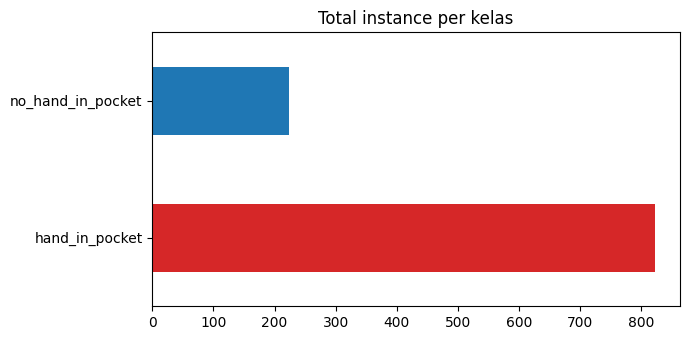

In [3]:
def count_dist(split):
    counts = {i: 0 for i in range(len(CLASS_NAMES))}
    d = PROC_DIR / split / 'labels'
    if not d.exists():
        return counts
    for lbl in d.glob('*.txt'):
        for line in lbl.read_text().splitlines():
            line = line.strip()
            if line:
                counts[int(line.split()[0])] = counts.get(int(line.split()[0]), 0) + 1
    return counts

dist = {s: count_dist(s) for s in SPLITS}
dist_df = pd.DataFrame(dist).fillna(0).astype(int)
dist_df.index = [CLASS_NAMES[i] for i in dist_df.index]
dist_df['total'] = dist_df.sum(axis=1)
n_img = {s: len(list((PROC_DIR / s / 'images').glob('*'))) for s in SPLITS}
print('Gambar per split:', n_img)
print()
print(dist_df.to_string())

# ukuran bbox
rows = []
for lbl in (PROC_DIR / 'train' / 'labels').glob('*.txt'):
    for line in lbl.read_text().splitlines():
        p = line.split()
        if len(p) == 5:
            rows.append({'class': CLASS_NAMES[int(p[0])], 'w': float(p[3]), 'h': float(p[4])})
bb = pd.DataFrame(rows)
bb['area'] = bb['w'] * bb['h']
print()
print('Statistik bbox (train, relatif):')
print(bb[['w', 'h', 'area']].describe().round(4).to_string())
small = (bb['area'] < 0.01).mean() * 100
print(f'\nBbox kecil (area<1%): {small:.1f}%  -> kalau >30%, pertimbangkan imgsz=1280')

fig, ax = plt.subplots(figsize=(7, 3.5))
dist_df['total'].plot.barh(ax=ax, color=['#d62728', '#1f77b4'])
ax.set_title('Total instance per kelas')
plt.tight_layout(); plt.show()

## (Opsional) Gabung dataset #2 — Fase A.2

Dataset #2 (`segmentation-hand-in-pocket`) hanya punya kelas positif `hand_in_pocket` (no negatif). Menambahnya menaikkan recall tapi tidak menambah contoh negatif. Polygon di #2 otomatis dikonversi ke bbox.

Set `MERGE_DATASET_2 = True` untuk menjalankan. Nama file diberi prefix `d2_` supaya tidak bentrok.

In [4]:
MERGE_DATASET_2 = False

if MERGE_DATASET_2:
    if not RAW2_DIR.exists():
        raise FileNotFoundError(RAW2_DIR)
    # #2 kelas 0 (hand_in_pocket) -> 0 di skema kita. tag 's2' (cegah bentrok nama).
    n2 = build_from(RAW2_DIR, class_map={0: 0}, tag='s2')
    print('Merge #2 selesai:', n2)
    print('Jalankan ulang sel Profil untuk lihat distribusi terbaru.')
else:
    print('Skip merge #2. Set MERGE_DATASET_2=True kalau mau gabung.')

Skip merge #2. Set MERGE_DATASET_2=True kalau mau gabung.


## Sample gambar + bbox

Sanity check kualitas label setelah konversi.

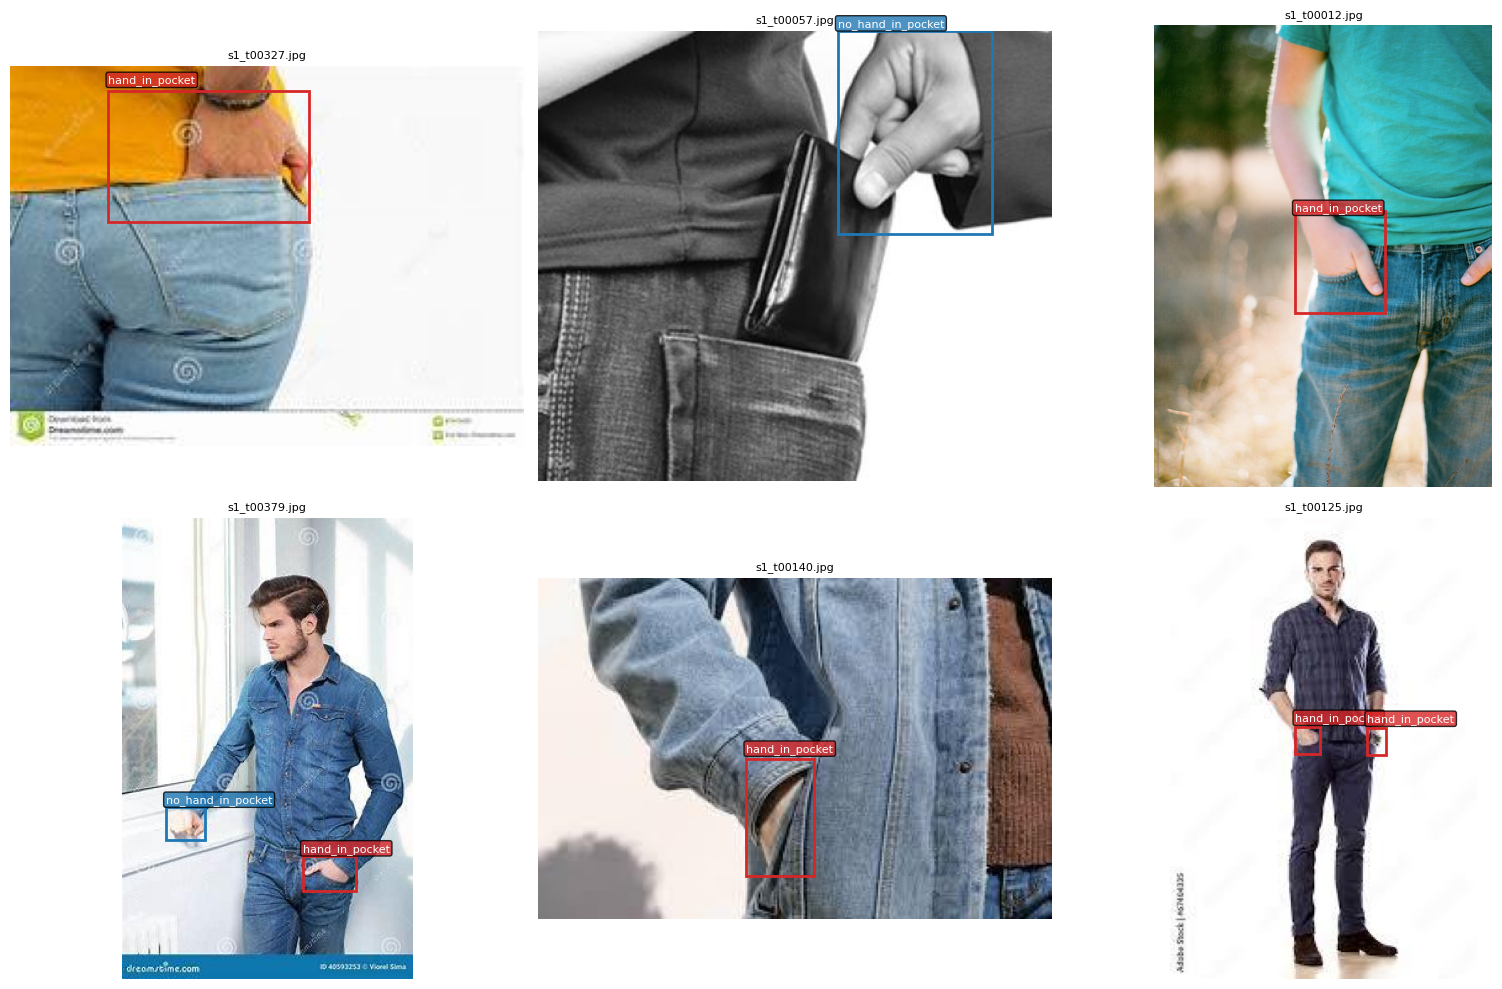

In [5]:
N = 6
imgs = sorted((PROC_DIR / 'train' / 'images').glob('*'))
samples = random.Random(SEED).sample(imgs, min(N, len(imgs)))
COLORS = {0: '#d62728', 1: '#1f77b4'}
cols = 3
rows_n = (len(samples) + cols - 1) // cols
fig, axes = plt.subplots(rows_n, cols, figsize=(16, 5 * rows_n))
axes = axes.flatten()
for ax, ip in zip(axes, samples):
    img = Image.open(ip); w, h = img.size; ax.imshow(img)
    lp = PROC_DIR / 'train' / 'labels' / (ip.stem + '.txt')
    if lp.exists():
        for line in lp.read_text().splitlines():
            p = line.split()
            if len(p) != 5:
                continue
            cls = int(p[0]); cx, cy, bw, bh = [float(v) for v in p[1:]]
            x1, y1 = (cx - bw / 2) * w, (cy - bh / 2) * h
            ax.add_patch(patches.Rectangle((x1, y1), bw * w, bh * h, lw=2,
                         edgecolor=COLORS.get(cls, 'lime'), facecolor='none'))
            ax.text(x1, y1 - 4, CLASS_NAMES[cls], fontsize=8, color='white',
                    bbox=dict(boxstyle='round,pad=0.2', fc=COLORS.get(cls, 'lime'), alpha=0.8))
    ax.set_title(ip.name[:40], fontsize=8); ax.axis('off')
for ax in axes[len(samples):]:
    ax.axis('off')
plt.tight_layout(); plt.show()

## Selesai

Dataset siap di `processed/hand_in_pocket/`. Lanjut ke **`02_train.ipynb`** untuk training YOLO26m.

Kalau recall `no_hand_in_pocket` jelek (kelas minoritas), pertimbangkan gabung dataset #2 atau augmentasi saat training.